# Exploratory Data Analysis (EDA) Project

## Objective
The objective of this project is to analyze a dataset to identify:
- Patterns
- Trends
- Distributions
- Outliers
- Relationships between variables

The project focuses on transforming raw data into actionable analytical insights using Python and data visualization techniques.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/cleaned_ecommerce_data.csv")
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB


OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

# Feature Engineering

Additional analytical columns were created to improve trend analysis and support deeper exploration of customer behavior and transaction patterns.

In [4]:
df["Year"] = pd.to_datetime(df["Date"]).dt.year

df["Month"] = pd.to_datetime(df["Date"]).dt.month_name()

df["Day"] = pd.to_datetime(df["Date"]).dt.day_name()

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [5]:
df.describe()
df[[
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "Revenue"
]].describe()

,Quantity,UnitPrice,ItemsInCart,Revenue
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


# Univariate Analysis

Univariate analysis was performed to understand the distribution, spread, and concentration of individual variables within the dataset.

The analysis focuses on:
- Revenue distribution
- Product pricing behavior
- Cart size distribution
- Transaction quantity patterns

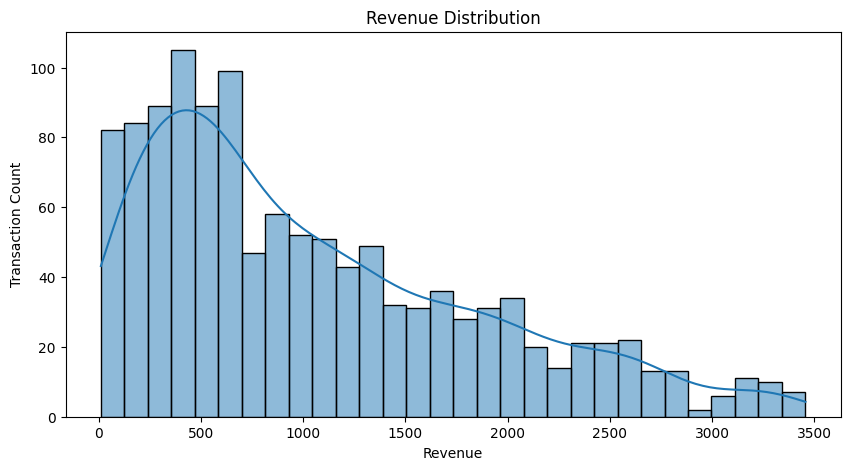

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Revenue"], bins=30, kde=True)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Transaction Count")

plt.show()

### Observation

The revenue distribution is positively skewed, with most transactions concentrated in the lower-to-mid revenue range.

A smaller number of high-value transactions extend the distribution toward the higher revenue side, indicating the presence of premium purchasing behavior.

No extreme anomalous outliers were visually identified, suggesting that the dataset remains reasonably consistent while still capturing revenue variability across customers.


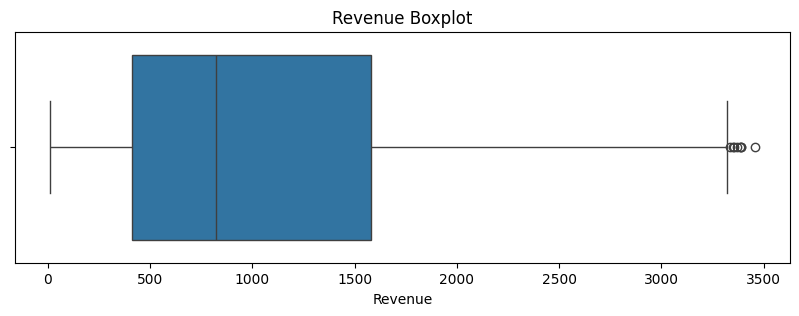

In [7]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=df["Revenue"])

plt.title("Revenue Boxplot")

plt.show()

### Observation

The revenue boxplot reveals a positively skewed distribution with several high-value transaction outliers on the upper revenue range.

The longer right whisker confirms the presence of higher spending transactions extending beyond the typical revenue range.

The middle 50% of transactions shows moderate variability, indicating diverse customer purchasing behavior across the dataset.

The detected outliers appear to represent legitimate high-value purchases rather than data quality issues.

In [8]:
product_revenue = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: Revenue, dtype: float64

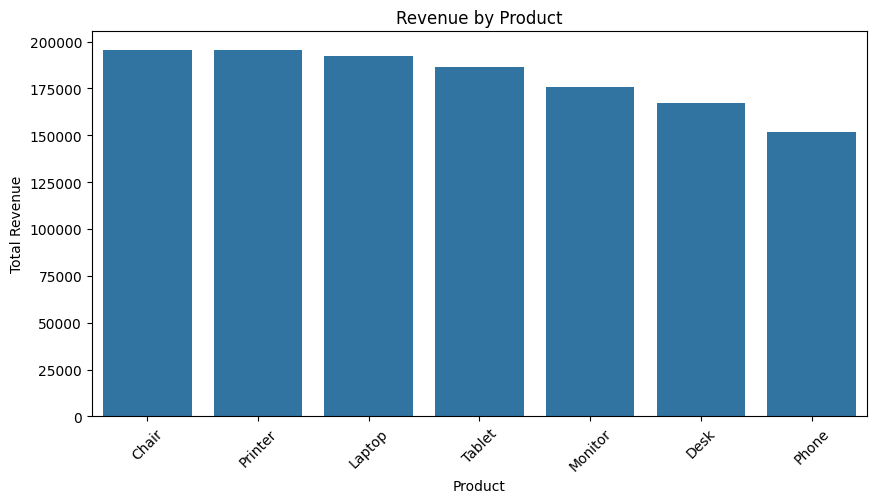

In [9]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=product_revenue.index,
    y=product_revenue.values
)

plt.title("Revenue by Product")

plt.xlabel("Product")

plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

### Observation

Revenue contribution across products appears relatively balanced, with no single product category overwhelmingly dominating total sales.

Chairs and Printers generated the highest total revenue, while Phones contributed the lowest revenue among the listed products.

The relatively even revenue distribution suggests a diversified product portfolio and balanced customer purchasing behavior across categories.

In [10]:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
    .reindex([
        "January", "February", "March",
        "April", "May", "June",
        "July", "August", "September",
        "October", "November", "December"
    ])
)

monthly_revenue

Month
January      124313.23
February     112344.78
March        123840.93
April        109186.05
May          135142.59
June         170616.13
July          85784.64
August        86343.21
September     69321.65
October       89834.82
November      75493.43
December      82540.50
Name: Revenue, dtype: float64

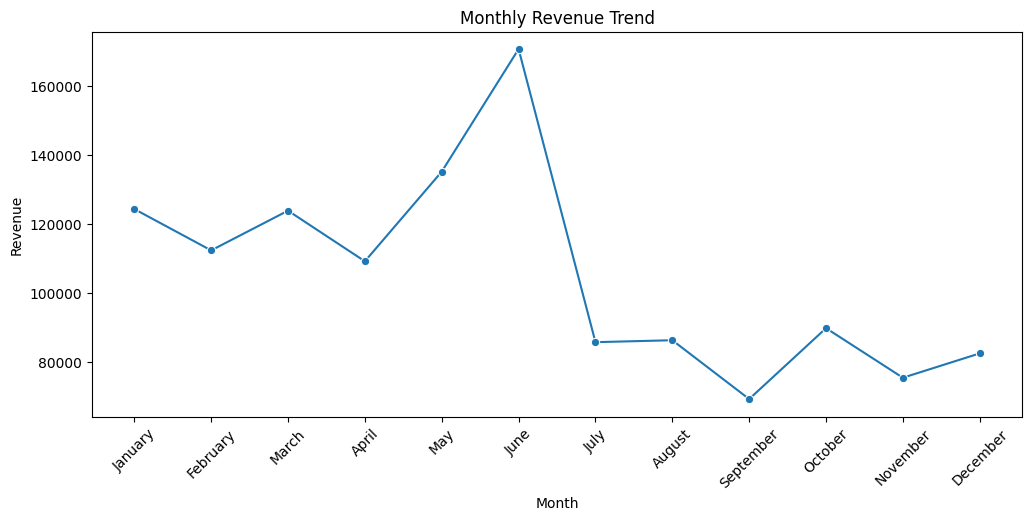

In [11]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### Observation

Monthly revenue trends show noticeable volatility across the year, indicating fluctuating purchasing behavior over time.

Revenue steadily increased between April and June, with June recording the highest overall revenue performance.

A significant revenue decline occurred immediately after June, suggesting the possibility of seasonal demand concentration or temporary sales-driving factors.

The trend pattern indicates that customer purchasing activity is not evenly distributed throughout the year.

In [12]:
correlation = df[[
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "Revenue"
]].corr()

correlation

,Quantity,UnitPrice,ItemsInCart,Revenue
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
Revenue,0.615251,0.717081,0.392540,1.000000


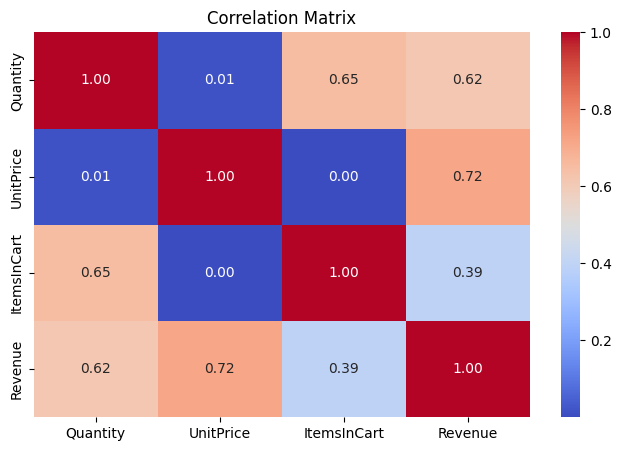

In [13]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Observation

Revenue shows strong positive correlations with both UnitPrice (0.72) and Quantity (0.62), indicating that higher-priced products and larger purchase quantities contribute significantly to overall revenue generation.

ItemsInCart demonstrates a moderate correlation with Revenue (0.39), suggesting that cart size alone has less influence on revenue compared to pricing and quantity.

The near-zero correlation between Quantity and UnitPrice indicates that customers are not necessarily purchasing larger quantities of higher-priced products.

These relationships highlight pricing and purchase volume as key drivers of transaction revenue within the dataset.

In [14]:
Q1 = df["Revenue"].quantile(0.25)

Q3 = df["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Revenue"] < lower_bound) |
    (df["Revenue"] > upper_bound)
]

outliers.shape

(8, 18)

In [15]:
outliers[[
    "Product",
    "Quantity",
    "UnitPrice",
    "Revenue"
]].head(10)

,Product,Quantity,UnitPrice,Revenue
107,Printer,5,670.75,3353.75
326,Laptop,5,670.48,3352.40
328,Tablet,5,674.04,3370.20
469,Chair,5,676.98,3384.90
632,Laptop,5,678.16,3390.80
789,Tablet,5,691.28,3456.40
1065,Printer,5,666.80,3334.00
1122,Monitor,5,678.19,3390.95


### Observation

IQR-based outlier detection identified several high-revenue transactions concentrated in the upper revenue range.

The detected outliers consistently involve:
- High unit-priced products
- Maximum purchase quantities

This indicates that the outliers represent legitimate high-value transactions rather than data quality issues.

The pattern suggests that revenue spikes are primarily driven by the combination of premium-priced products and larger order quantities.

# Key Business Insights
1. Revenue distribution is positively skewed, indicating the presence of high-value transactions that contribute disproportionately to total revenue.

2. Revenue trends show strong monthly fluctuations, with June emerging as the highest-performing month.

3. Product revenue contribution is relatively balanced, suggesting diversified customer demand across product categories.

4. UnitPrice and Quantity are the strongest drivers of Revenue, based on correlation analysis.

5. Statistical outlier analysis revealed that high-revenue transactions are legitimate premium purchases rather than data anomalies.

6. Customer purchasing behavior demonstrates substantial variability across transaction values and cart sizes.

# Business Recommendations

- Investigate the factors contributing to June’s revenue spike to identify repeatable sales opportunities.

- Develop strategies targeting high-value customers and premium purchase behavior.

- Focus on pricing and quantity optimization, as both strongly influence revenue generation.

- Monitor high-value transactions separately for customer segmentation and personalized marketing opportunities.

- Continue tracking monthly purchasing trends to better understand seasonal demand patterns.